# QS Subject Rankings — Citations per Paper Score Calculator
## **Engineering & Technology** (Broad Faculty Area) — PUCV

Este notebook calcula el **puntaje bruto de Citations per Paper (CPP)** que obtendría
una institución para cada año de evaluación posible, siguiendo la metodología oficial
de QS World University Rankings by Subject.

Combina los datos de **tres áreas disciplinares** que conforman el broad area
Engineering & Technology en QS:
- **Engineering** (`PAPERS EN ENGINEERING PUCV.csv`)
- **Chemical Engineering** (`PAPERS EN CHEMICAL ENGINEERING PUCV.csv`)
- **Computer Science** (`PAPERS EN COMPUTER SCIENCE PUCV.csv`)

### Metodología aplicada
| Parámetro | Valor |
|---|---|
| Ventana de publicación (P) | 5 años |
| Ventana de citas (C) | 6 años desde el año de publicación |
| Tipos incluidos | Article, Review, Conference Paper, Book, Book Chapter, Editorial, Note |
| Tipos excluidos | Erratum, Conference Review |
| Deduplicación | Papers duplicados entre CSVs se cuentan una sola vez |
| Journals de nicho (1 ASJC) | Peso doble en citas (**no aplicable sin datos de journal**) |
| Sliding scale | Reducción de citas si P < 10×T (T = paper threshold del subject) |
| Normalización FA | **No aplica** en Subject Rankings |
| Scoring | z-score → escala [0, 100] |

> **Nota sobre deduplicación:** Un mismo paper puede aparecer en más de un CSV
> si fue clasificado bajo múltiples disciplinas en Scopus. El notebook detecta
> y elimina duplicados exactos por (año + citas + tipo) para no inflar P ni C.

---

## 0. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import io
import warnings
warnings.filterwarnings('ignore')
print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


## 1. Carga y combinacion de los tres CSV

Sube los tres archivos cuando el dialogo lo solicite (puedes seleccionarlos todos a la vez).

In [ ]:
from google.colab import files

# Nombres esperados (el script busca coincidencia parcial, sin distinguir mayusculas)
EXPECTED = {
    'engineering'         : 'PAPERS EN ENGINEERING USM',
    'chemical_engineering': 'PAPERS EN CHEMICAL ENGINEERING USM',
    'computer_science'    : 'PAPERS EN COMPUTER SCIENCE USM',
}

print('Sube los tres archivos CSV:')
for k, v in EXPECTED.items():
    print(f'  - {v}.csv')
print()

# --- OPCION A: subir desde tu PC (por defecto) ---
uploaded = files.upload()

# --- OPCION B: Google Drive (descomenta si prefieres) ---
# from google.colab import drive
# drive.mount('/content/drive')
# RUTA = '/content/drive/MyDrive/'   # <- ajusta
# uploaded = {}
# for k, v in EXPECTED.items():
#     fname = v + '.csv'
#     uploaded[fname] = open(RUTA + fname, 'rb').read()

# Cargar cada CSV identificandolo por nombre
dfs_por_area = {}
for label, patron in EXPECTED.items():
    match = [k for k in uploaded.keys()
             if patron.lower().replace(' ', '') in k.lower().replace(' ', '')]
    if not match:
        print(f'AVISO: no se encontro archivo para "{patron}". Verifica el nombre.')
        continue
    key = match[0]
    df_tmp = pd.read_csv(io.BytesIO(uploaded[key]))
    df_tmp['area'] = label
    dfs_por_area[label] = df_tmp
    print(f'OK  {label:25s} -> {len(df_tmp):>5,} filas  ({key})')

assert len(dfs_por_area) == 3, f'Se esperaban 3 CSV, se cargaron {len(dfs_por_area)}. Revisa los nombres.'

Sube los tres archivos CSV:
  - PAPERS EN ENGINEERING USM.csv
  - PAPERS EN CHEMICAL ENGINEERING USM.csv
  - PAPERS EN COMPUTER SCIENCE USM.csv



Saving PAPERS EN CHEMICAL ENGINEERING USM.csv to PAPERS EN CHEMICAL ENGINEERING USM (4).csv
Saving PAPERS EN COMPUTER SCIENCE USM.csv to PAPERS EN COMPUTER SCIENCE USM (4).csv
Saving PAPERS EN ENGINEERING USM.csv to PAPERS EN ENGINEERING USM (4).csv
OK  engineering               -> 4,829 filas  (PAPERS EN ENGINEERING USM (4).csv)
OK  chemical_engineering      ->   783 filas  (PAPERS EN CHEMICAL ENGINEERING USM (4).csv)
OK  computer_science          -> 2,712 filas  (PAPERS EN COMPUTER SCIENCE USM (4).csv)


## 2. Limpieza, union y deduplicacion

In [ ]:
EXCLUDED_TYPES = {'Erratum', 'Conference review', 'Conference Review'}

def limpiar(df_raw, area_label):
    df = df_raw.rename(columns={
        'Year': 'pub_year',
        'Cited by': 'citations_raw',
        'Document Type': 'doc_type',
        'DOI': 'doi',
        'EID': 'eid'
    }).copy()

    df['doc_type'] = df['doc_type'].astype(str).str.strip()

    # Normalización de DOI y EID
    df['doi'] = (
        df['doi']
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({'nan': np.nan, '': np.nan})
    )

    df['eid'] = (
        df['eid']
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({'nan': np.nan, '': np.nan})
    )

    df['pub_year']      = pd.to_numeric(df['pub_year'], errors='coerce')
    df['citations_raw'] = pd.to_numeric(df['citations_raw'], errors='coerce').fillna(0).astype(int)

    df = df.dropna(subset=['pub_year'])
    df['pub_year'] = df['pub_year'].astype(int)

    df['area']        = area_label
    df['qs_included'] = ~df['doc_type'].isin(EXCLUDED_TYPES)

    return df

dfs_limpios = [limpiar(v, k) for k, v in dfs_por_area.items()]
df_concat   = pd.concat(dfs_limpios, ignore_index=True)

print(f'Filas concatenadas (con posibles duplicados): {len(df_concat):,}')

# ==========================================================
# DEDUPLICACIÓN USANDO DOI Y EID
# ==========================================================
# Prioridad:
# 1. DOI  -> identificador principal
# 2. EID  -> respaldo cuando DOI no existe
#
# Se eliminan duplicados:
# - primero por DOI
# - luego por EID solamente en registros sin DOI
# ==========================================================

n_antes = len(df_concat)

# -----------------------------
# REGISTROS CON DOI
# -----------------------------
df_con_doi = (
    df_concat[df_concat['doi'].notna()]
    .drop_duplicates(subset=['doi'], keep='first')
)

# -----------------------------
# REGISTROS SIN DOI
# -----------------------------
df_sin_doi = df_concat[df_concat['doi'].isna()]

df_sin_doi = (
    df_sin_doi
    .drop_duplicates(subset=['eid'], keep='first')
)

# -----------------------------
# COMBINAR RESULTADOS
# -----------------------------
df = (
    pd.concat([df_con_doi, df_sin_doi], ignore_index=True)
    .reset_index(drop=True)
)

n_dup = n_antes - len(df)

print(f'Duplicados eliminados           : {n_dup:,}')
print(f'Filas únicas                    : {len(df):,}')
print(f'  Incluidas por QS              : {df["qs_included"].sum():,}')
print(f'  Excluidas por QS (errata etc) : {(~df["qs_included"]).sum():,}')

print('\n--- Papers por área (tras deduplicación) ---')
print(df.groupby('area').size().rename('papers').to_string())

print('\n--- Tipos de documento en el dataset combinado ---')
print(df['doc_type'].value_counts().to_string())

Filas concatenadas (con posibles duplicados): 8,324
Duplicados eliminados           : 1,752
Filas únicas                    : 6,572
  Incluidas por QS              : 6,536
  Excluidas por QS (errata etc) : 36

--- Papers por área (tras deduplicación) ---
area
chemical_engineering     490
computer_science        1259
engineering             4823

--- Tipos de documento en el dataset combinado ---
doc_type
Article             3663
Conference paper    2426
Book chapter         224
Review                94
Editorial             86
Erratum               36
Note                  16
Short survey           9
Letter                 8
Book                   7
Data paper             2
Retracted              1


## 3. Configuracion de parametros

In [ ]:
# ===========================================================
#  PARAMETROS CONFIGURABLES
# ===========================================================

PUBLICATION_WINDOW = 5    # anos de publicacion
CITATION_WINDOW    = 6    # anos de citas (referencia; no cambia el calculo con datos actuales)

# Paper threshold T para Engineering & Technology (broad area, 3 disciplinas)
# Estimado conservador: 100 papers. Ajustar si se conoce el valor oficial del subject.
# Corresponde al número mínimo de papers que debe tener una institución para ser incluida en un subject.
# Está aqui por formalidad, se puede eliminar sin problemas.
PAPER_THRESHOLD = 100

# Rango de anos a simular
MIN_EVAL_YEAR = 2018
MAX_EVAL_YEAR = 2026

# Parametros de distribucion global de CPP en E&T (para estimar score [0-100])
# Reemplaza con datos reales si se obtienen.
MU_CPP    = 3.5
SIGMA_CPP = 4.0
Z_MIN     = -1.5
Z_MAX     =  5.0

print('Parametros configurados:')
print(f'  Ventana publicacion: {PUBLICATION_WINDOW} anos')
print(f'  Paper threshold T  : {PAPER_THRESHOLD}')
print(f'  Anos evaluacion    : {MIN_EVAL_YEAR} - {MAX_EVAL_YEAR}')
print(f'  mu_CPP / sigma_CPP : {MU_CPP} / {SIGMA_CPP}  (estimados)')

Parametros configurados:
  Ventana publicacion: 5 anos
  Paper threshold T  : 100
  Anos evaluacion    : 2018 - 2026
  mu_CPP / sigma_CPP : 3.5 / 4.0  (estimados)


## 4. Funcion principal de calculo CPP

In [ ]:
def calcular_cpp(df_papers, anio_base, pub_window, threshold):
    """
    Calcula Citations per Paper (CPP) segun metodologia QS para un ano base dado.

    Variables
    ---------
    P             : numero de papers en la ventana de publicacion
    C_total       : suma de citas brutas de esos papers
    T             : paper threshold del subject
    sliding_factor: factor de reduccion cuando T < P < 10*T
    Definición sliding_factor: If a university falls below the minimum publication threshold for a specific subject, its citation count is reduced on a sliding scale by up to \(10\) times the required threshold.
    C_adj         : citas ajustadas = C_total * sliding_factor
    CPP           : Citations per Paper = C_adj / P
    """
    pub_start = anio_base - pub_window   # primer ano de la ventana
    pub_end   = anio_base - 1           # ultimo ano de la ventana

    mask  = (
        df_papers['qs_included'] &
        (df_papers['pub_year'] >= pub_start) &
        (df_papers['pub_year'] <= pub_end)
    )
    df_v    = df_papers[mask]
    P       = len(df_v)
    C_total = int(df_v['citations_raw'].sum())

    # Sliding scale
    if P <= threshold:
        califica, sliding_factor, C_adj = False, 0.0, 0.0
    elif P < 10 * threshold:
        califica       = True
        sliding_factor = (P - threshold) / (9 * threshold)
        C_adj          = C_total * sliding_factor
    else:
        califica, sliding_factor, C_adj = True, 1.0, float(C_total)

    CPP = C_adj / P if P > 0 else 0.0

    # Desglose por area
    p_area = df_v.groupby('area').size().to_dict()
    c_area = df_v.groupby('area')['citations_raw'].sum().to_dict()

    return {
        'anio_base'     : anio_base,
        'pub_start'     : pub_start,
        'pub_end'       : pub_end,
        'P'             : P,
        'P_engineering' : p_area.get('engineering', 0),
        'P_chemical'    : p_area.get('chemical_engineering', 0),
        'P_cs'          : p_area.get('computer_science', 0),
        'C_total'       : C_total,
        'C_engineering' : int(c_area.get('engineering', 0)),
        'C_chemical'    : int(c_area.get('chemical_engineering', 0)),
        'C_cs'          : int(c_area.get('computer_science', 0)),
        'T'             : threshold,
        'califica'      : califica,
        'sliding_factor': round(sliding_factor, 4),
        'C_adj'         : round(C_adj, 2),
        'CPP'           : round(CPP, 4),
    }


def score_qs(cpp, mu, sigma, z_min, z_max):
    """Transforma CPP a score [0,100] via z-score escalado."""
    if cpp == 0:
        return 0.0
    z = (cpp - mu) / sigma
    return round(max(0.0, min(100.0, (z - z_min) / (z_max - z_min) * 100)), 2)


print('Funciones definidas.')

Funciones definidas.


## 5. Calculo para todos los anos de evaluacion

In [ ]:
resultados = []
for anio in range(MIN_EVAL_YEAR, MAX_EVAL_YEAR + 1):
    res = calcular_cpp(df, anio, PUBLICATION_WINDOW, PAPER_THRESHOLD)
    res['z_score']              = round((res['CPP'] - MU_CPP) / SIGMA_CPP, 4) if res['CPP'] > 0 else 0.0
    res['score_estimado_0_100'] = score_qs(res['CPP'], MU_CPP, SIGMA_CPP, Z_MIN, Z_MAX)
    resultados.append(res)

df_res = pd.DataFrame(resultados)

pd.set_option('display.float_format', '{:.4f}'.format)
print('=== Tabla resumen ===')
print(df_res[[
    'anio_base','pub_start','pub_end',
    'P','C_total','T',
    'califica','sliding_factor','C_adj',
    'CPP','z_score','score_estimado_0_100'
]].to_string(index=False))

=== Tabla resumen ===
 anio_base  pub_start  pub_end    P  C_total   T  califica  sliding_factor      C_adj     CPP  z_score  score_estimado_0_100
      2018       2013     2017 1467    47068 100      True          1.0000 47068.0000 32.0845   7.1461              100.0000
      2019       2014     2018 1577    45498 100      True          1.0000 45498.0000 28.8510   6.3377              100.0000
      2020       2015     2019 1708    46140 100      True          1.0000 46140.0000 27.0141   5.8785              100.0000
      2021       2016     2020 1850    43965 100      True          1.0000 43965.0000 23.7649   5.0662              100.0000
      2022       2017     2021 1952    42868 100      True          1.0000 42868.0000 21.9611   4.6153               94.0800
      2023       2018     2022 1961    38644 100      True          1.0000 38644.0000 19.7063   4.0516               85.4100
      2024       2019     2023 2091    35854 100      True          1.0000 35854.0000 17.1468   3.4117 

## 6. Desglose detallado por ano

In [ ]:
print('=' * 70)
print('DESGLOSE DETALLADO — Engineering + Chemical Eng. + Computer Science')
print('=' * 70)

for _, row in df_res.iterrows():
    print(f"\n{'─'*70}")
    print(f"  Ano de evaluacion QS  : {int(row['anio_base'])}")
    print(f"  Ventana publicacion   : {int(row['pub_start'])} - {int(row['pub_end'])}")
    print(f"  Papers totales (P)    : {int(row['P'])}")
    print(f"    Engineering         : {int(row['P_engineering'])}")
    print(f"    Chemical Eng.       : {int(row['P_chemical'])}")
    print(f"    Computer Science    : {int(row['P_cs'])}")
    print(f"  Threshold (T)         : {int(row['T'])}")
    print(f"  Califica              : {'SI' if row['califica'] else 'NO (P <= T)'}")

    if row['califica']:
        print(f"  Citas brutas (C)      : {int(row['C_total'])}")
        print(f"    Engineering         : {int(row['C_engineering'])}")
        print(f"    Chemical Eng.       : {int(row['C_chemical'])}")
        print(f"    Computer Science    : {int(row['C_cs'])}")
        sf = row['sliding_factor']
        penalizacion = '' if sf >= 1.0 else f'  (P={int(row["P"])} < 10xT={10*int(row["T"])})'
        print(f"  Sliding factor        : {sf:.4f}{penalizacion}")
        print(f"  Citas ajustadas (C')  : {row['C_adj']:.2f}")
        print(f"  CPP = C' / P          : {row['CPP']:.4f}")
        print(f"  z-score (estimado)    : {row['z_score']:.4f}")
        print(f"  Score QS [0-100]      : {row['score_estimado_0_100']:.2f}  <- estimado")

print(f"\n{'─'*70}")
print('Score [0-100] es estimacion; requiere distribucion global de CPP de QS.')

DESGLOSE DETALLADO — Engineering + Chemical Eng. + Computer Science

──────────────────────────────────────────────────────────────────────
  Ano de evaluacion QS  : 2018
  Ventana publicacion   : 2013 - 2017
  Papers totales (P)    : 1467
    Engineering         : 1119
    Chemical Eng.       : 71
    Computer Science    : 277
  Threshold (T)         : 100
  Califica              : SI
  Citas brutas (C)      : 47068
    Engineering         : 41504
    Chemical Eng.       : 1647
    Computer Science    : 3917
  Sliding factor        : 1.0000
  Citas ajustadas (C')  : 47068.00
  CPP = C' / P          : 32.0845
  z-score (estimado)    : 7.1461
  Score QS [0-100]      : 100.00  <- estimado

──────────────────────────────────────────────────────────────────────
  Ano de evaluacion QS  : 2019
  Ventana publicacion   : 2014 - 2018
  Papers totales (P)    : 1577
    Engineering         : 1188
    Chemical Eng.       : 85
    Computer Science    : 304
  Threshold (T)         : 100
  Califica  

## 7. Desglose por area y tipo de documento (ano seleccionado)

In [ ]:
ANIO_DETALLE = 2026   # <- cambia aqui

pub_s = ANIO_DETALLE - PUBLICATION_WINDOW
pub_e = ANIO_DETALLE - 1

df_det = df[
    df['qs_included'] &
    (df['pub_year'] >= pub_s) &
    (df['pub_year'] <= pub_e)
].copy()

print(f'Ano base {ANIO_DETALLE} | Ventana {pub_s}-{pub_e} | Papers: {len(df_det):,}')

print('\n--- Por area disciplinar ---')
r_area = df_det.groupby('area').agg(
    papers=('citations_raw','count'),
    citas =('citations_raw','sum'),
    media =('citations_raw','mean'),
    mediana=('citations_raw','median'),
    maximo=('citations_raw','max')
).reset_index()
r_area['CPP'] = (r_area['citas'] / r_area['papers']).round(4)
r_area['media'] = r_area['media'].round(2)
print(r_area.to_string(index=False))

print('\n--- Por tipo de documento ---')
r_tipo = df_det.groupby('doc_type').agg(
    papers=('citations_raw','count'),
    citas =('citations_raw','sum'),
    media =('citations_raw','mean'),
    maximo=('citations_raw','max')
).reset_index().sort_values('citas', ascending=False)
r_tipo['CPP']   = (r_tipo['citas'] / r_tipo['papers']).round(4)
r_tipo['media'] = r_tipo['media'].round(2)
print(r_tipo.to_string(index=False))

print(f'\n--- Papers y citas por ano de publicacion (ventana {pub_s}-{pub_e}) ---')
por_anio = df_det.groupby('pub_year').agg(
    papers=('citations_raw','count'),
    citas =('citations_raw','sum')
).reset_index()
por_anio['CPP_anual'] = (por_anio['citas'] / por_anio['papers']).round(4)
print(por_anio.to_string(index=False))

Ano base 2026 | Ventana 2021-2025 | Papers: 2,163

--- Por area disciplinar ---
                area  papers  citas   media  mediana  maximo     CPP
chemical_engineering     191   2169 11.3600   6.0000     126 11.3560
    computer_science     366   2727  7.4500   3.0000     123  7.4508
         engineering    1606  17150 10.6800   3.0000     541 10.6787

--- Por tipo de documento ---
        doc_type  papers  citas   media  maximo     CPP
         Article    1347  19174 14.2300     541 14.2346
          Review      45   1461 32.4700     147 32.4667
Conference paper     668   1217  1.8200      34  1.8219
    Book chapter      79     89  1.1300      12  1.1266
       Editorial      13     46  3.5400      41  3.5385
    Short survey       1     19 19.0000      19 19.0000
      Data paper       2     18  9.0000      15  9.0000
            Book       2     13  6.5000      12  6.5000
            Note       5      7  1.4000       3  1.4000
          Letter       1      2  2.0000       2  2.00

## 8. Visualizaciones

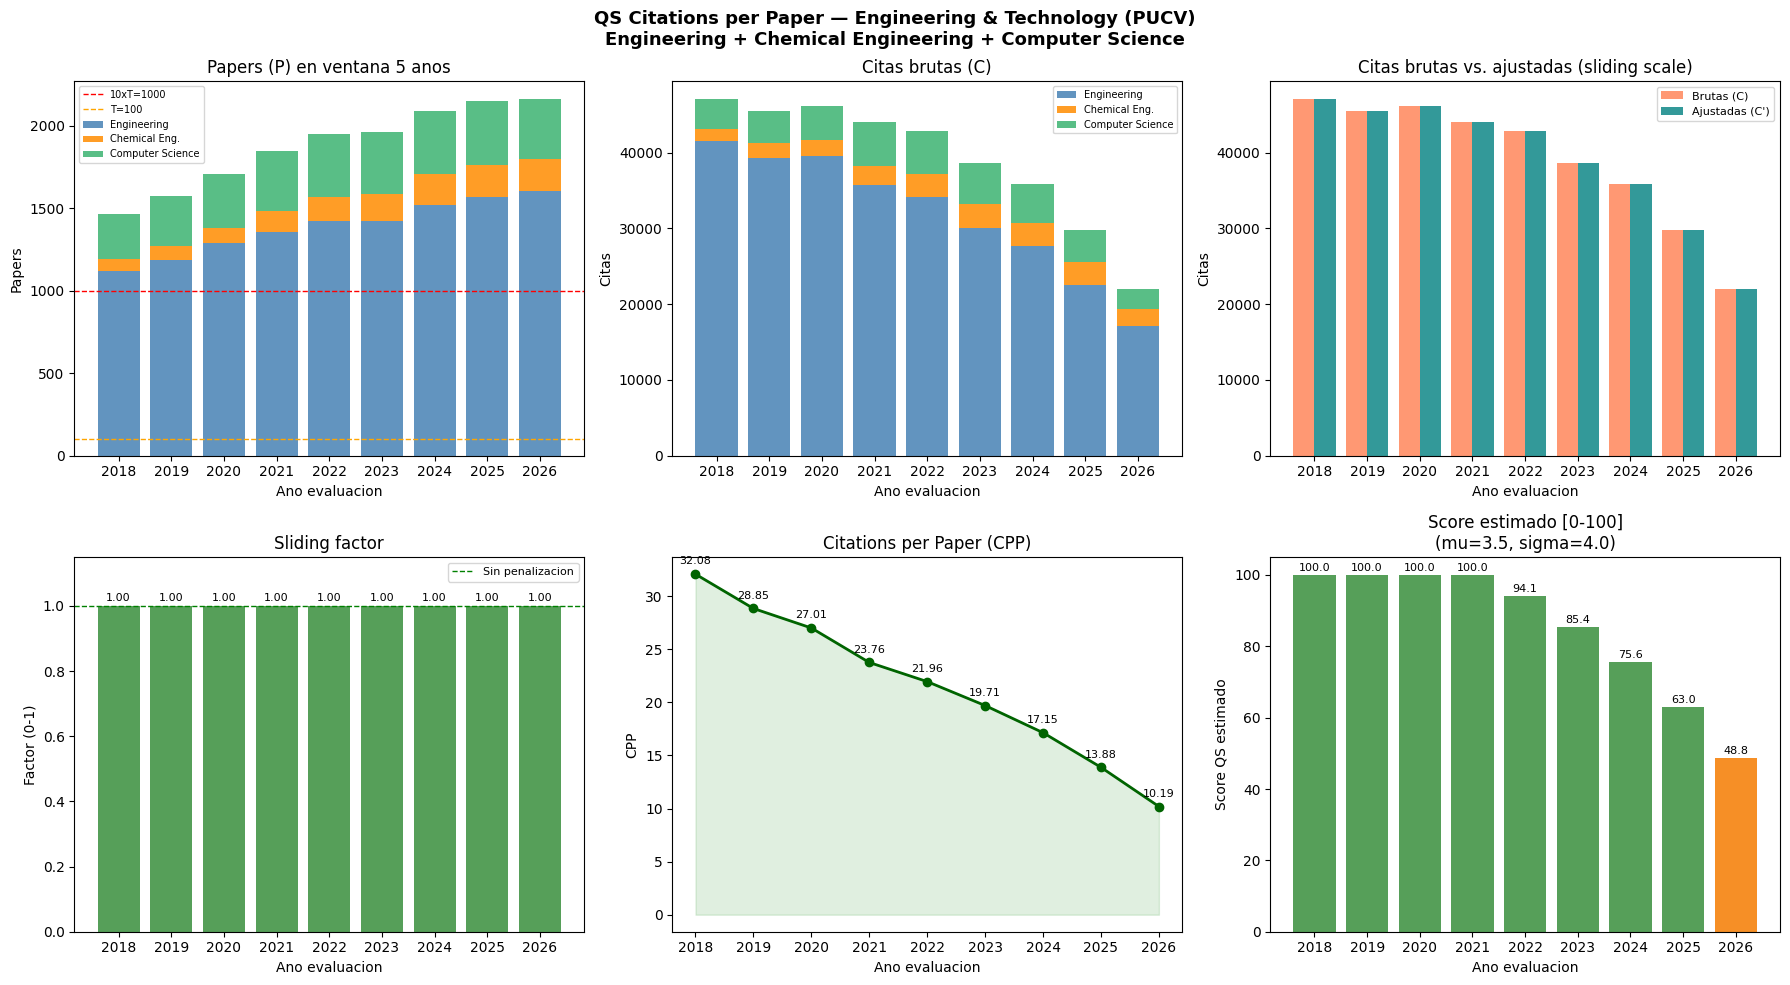

Grafico guardado como QS_Citations_PUCV.png


In [ ]:
df_plot = df_res[df_res['califica']].copy()
anios   = df_plot['anio_base'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'QS Citations per Paper — Engineering & Technology (PUCV)\n'
    'Engineering + Chemical Engineering + Computer Science',
    fontsize=13, fontweight='bold'
)

COLORES = {'engineering': 'steelblue', 'chemical_engineering': 'darkorange', 'computer_science': 'mediumseagreen'}
ETIQUETAS = {'engineering': 'Engineering', 'chemical_engineering': 'Chemical Eng.', 'computer_science': 'Computer Science'}

# Panel 1: Papers apilados por area
ax = axes[0, 0]
bottom = np.zeros(len(df_plot))
for col, color, label in [
    ('P_engineering', COLORES['engineering'],          ETIQUETAS['engineering']),
    ('P_chemical',    COLORES['chemical_engineering'], ETIQUETAS['chemical_engineering']),
    ('P_cs',          COLORES['computer_science'],     ETIQUETAS['computer_science']),
]:
    vals = df_plot[col].values
    ax.bar(anios, vals, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += vals
ax.axhline(PAPER_THRESHOLD * 10, color='red',    linestyle='--', lw=1, label=f'10xT={PAPER_THRESHOLD*10}')
ax.axhline(PAPER_THRESHOLD,      color='orange', linestyle='--', lw=1, label=f'T={PAPER_THRESHOLD}')
ax.set_title('Papers (P) en ventana 5 anos')
ax.set_xlabel('Ano evaluacion')
ax.set_ylabel('Papers')
ax.legend(fontsize=7)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 2: Citas brutas apiladas por area
ax = axes[0, 1]
bottom = np.zeros(len(df_plot))
for col, color, label in [
    ('C_engineering', COLORES['engineering'],          ETIQUETAS['engineering']),
    ('C_chemical',    COLORES['chemical_engineering'], ETIQUETAS['chemical_engineering']),
    ('C_cs',          COLORES['computer_science'],     ETIQUETAS['computer_science']),
]:
    vals = df_plot[col].values.astype(float)
    ax.bar(anios, vals, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += vals
ax.set_title('Citas brutas (C)')
ax.set_xlabel('Ano evaluacion')
ax.set_ylabel('Citas')
ax.legend(fontsize=7)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 3: Citas brutas vs ajustadas
ax = axes[0, 2]
ax.bar(anios - 0.2, df_plot['C_total'], width=0.4, label='Brutas (C)',    color='coral', alpha=0.8)
ax.bar(anios + 0.2, df_plot['C_adj'],   width=0.4, label="Ajustadas (C')",color='teal',  alpha=0.8)
ax.set_title('Citas brutas vs. ajustadas (sliding scale)')
ax.set_xlabel('Ano evaluacion')
ax.set_ylabel('Citas')
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 4: Sliding factor
ax = axes[1, 0]
sf_colors = ['#d32f2f' if sf < 0.5 else '#f57c00' if sf < 1.0 else '#388e3c'
             for sf in df_plot['sliding_factor']]
ax.bar(anios, df_plot['sliding_factor'], color=sf_colors, alpha=0.85)
ax.axhline(1.0, color='green', linestyle='--', lw=1, label='Sin penalizacion')
ax.set_ylim(0, 1.15)
ax.set_title('Sliding factor')
ax.set_xlabel('Ano evaluacion')
ax.set_ylabel('Factor (0-1)')
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for bar, val in zip(ax.patches, df_plot['sliding_factor']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8)

# Panel 5: CPP
ax = axes[1, 1]
ax.plot(anios, df_plot['CPP'], marker='o', color='darkgreen', linewidth=2)
ax.fill_between(anios, df_plot['CPP'], alpha=0.12, color='green')
for _, row in df_plot.iterrows():
    ax.annotate(f"{row['CPP']:.2f}", (row['anio_base'], row['CPP']),
                textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)
ax.set_title('Citations per Paper (CPP)')
ax.set_xlabel('Ano evaluacion')
ax.set_ylabel('CPP')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 6: Score estimado [0-100]
ax = axes[1, 2]
sc_colors = ['#d32f2f' if s < 30 else '#f57c00' if s < 50 else '#388e3c'
             for s in df_plot['score_estimado_0_100']]
bars = ax.bar(anios, df_plot['score_estimado_0_100'], color=sc_colors, alpha=0.85)
for bar, val in zip(bars, df_plot['score_estimado_0_100']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, 105)
ax.set_title(f'Score estimado [0-100]\n(mu={MU_CPP}, sigma={SIGMA_CPP})')
ax.set_xlabel('Ano evaluacion')
ax.set_ylabel('Score QS estimado')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('QS_Citations_PUCV.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado como QS_Citations_PUCV.png')

## 9. Exportar resultados

In [ ]:
output_csv = 'QS_Citations_Scores_PUCV.csv'
df_res.to_csv(output_csv, index=False)
print(f'Exportado: {output_csv}')

from google.colab import files
files.download(output_csv)
files.download('QS_Citations_PUCV.png')

Exportado: QS_Citations_Scores_PUCV.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Notas metodologicas

### Lo que este codigo implementa fielmente
- OK  Combinacion de **3 areas disciplinares** que conforman E&T en QS
- OK  **Deduplicacion** de papers que aparecen en mas de un CSV
- OK  Ventana de publicacion de **5 anos** (pub_start = anio_base - 5)
- OK  **Exclusion de Errata** y Conference Reviews
- OK  **Sliding scale**: C_adj = C x (P - T) / (9 x T) cuando T < P < 10T
- OK  Sin Faculty Area Normalization (correcto para Subject Rankings)
- OK  z-score -> escala [0, 100]
- OK  Desglose de papers y citas **por area** para trazabilidad

### Limitaciones por datos disponibles
- AVISO  **Deduplicacion aproximada:** Se usa (ano, citas, tipo) como clave.
  Sin DOI/EID no se puede garantizar deduplicacion exacta.
- AVISO  **Citas totales vs. ventana de 6 anos:** El CSV tiene citas acumuladas.
  Para papers de los ultimos 5 anos la diferencia es minima.
- AVISO  **Niche journals:** Sin datos de journal no se puede aplicar el
  doble peso a citas de journals con un solo ASJC code.
- AVISO  **Affiliation cap y self-citations:** Requieren datos de co-autoria y autores.
- AVISO  **Score final [0-100]:** Ajusta MU_CPP, SIGMA_CPP, Z_MIN y Z_MAX
  en la celda 3 con datos reales si los tienes.

# Borrador comparador

Cargando: pucv_engineering.csv
Cargando: pucv_cs.csv
Cargando: pucv_chem.csv
Cargando: usm_engineering.csv
Cargando: usm_cs.csv
Cargando: usm_chem.csv

TOTAL REGISTROS:
13970

Duplicados eliminados: 3,165
Registros finales: 10,805

REGISTROS QS:
10756

RESUMEN ANUAL
    university  pub_year  papers  citations  cit_per_paper
0         PUCV      1962       1          6         6.0000
1         PUCV      1971       2         37        18.5000
2         PUCV      1977       1         33        33.0000
3         PUCV      1979       1         10        10.0000
4         PUCV      1980       1          8         8.0000
..         ...       ...     ...        ...            ...
96         USM      2022     346       5445        15.7370
97         USM      2023     460       4387         9.5370
98         USM      2024     466       2265         4.8605
99         USM      2025     450        881         1.9578
100        USM      2026     147         25         0.1701

[101 rows x 5 columns]



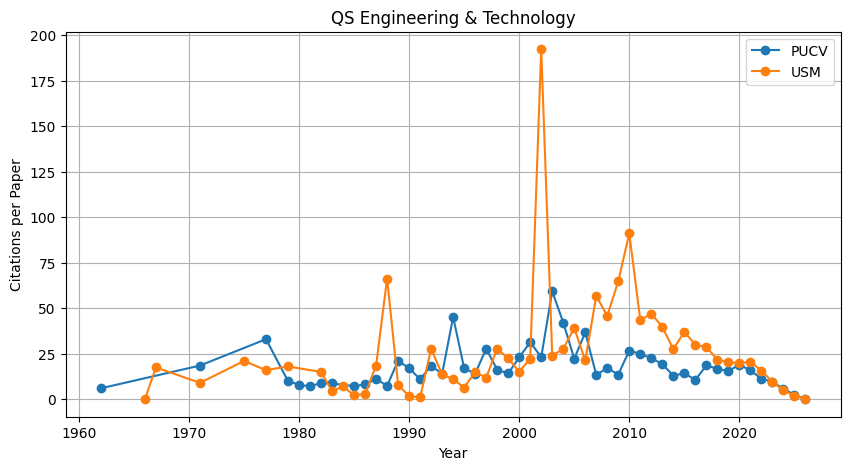

In [ ]:
# ==========================================================
# QS ENGINEERING & TECHNOLOGY
# COMPARACIÓN PUCV vs USM
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# CONFIGURACIÓN
# ==========================================================

EXCLUDED_TYPES = {
    'Erratum',
    'Conference review',
    'Conference Review'
}

# ==========================================================
# CSVs
# ==========================================================
# Reemplaza los nombres por tus archivos reales
# ==========================================================

csvs = {
    'PUCV': {
        'Engineering': 'pucv_engineering.csv',
        'Computer Science': 'pucv_cs.csv',
        'Chemical Engineering': 'pucv_chem.csv'
    },

    'USM': {
        'Engineering': 'usm_engineering.csv',
        'Computer Science': 'usm_cs.csv',
        'Chemical Engineering': 'usm_chem.csv'
    }
}

# ==========================================================
# FUNCIÓN LIMPIEZA
# ==========================================================

def limpiar(df_raw, university, area):

    df = df_raw.rename(columns={
        'Year': 'pub_year',
        'Cited by': 'citations_raw',
        'Document Type': 'doc_type',
        'DOI': 'doi',
        'EID': 'eid'
    }).copy()

    # ------------------------------------------------------
    # LIMPIEZA BÁSICA
    # ------------------------------------------------------

    df['doc_type'] = df['doc_type'].astype(str).str.strip()

    df['doi'] = (
        df['doi']
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({'nan': np.nan, '': np.nan})
    )

    df['eid'] = (
        df['eid']
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({'nan': np.nan, '': np.nan})
    )

    df['pub_year'] = pd.to_numeric(
        df['pub_year'],
        errors='coerce'
    )

    df['citations_raw'] = pd.to_numeric(
        df['citations_raw'],
        errors='coerce'
    ).fillna(0)

    df = df.dropna(subset=['pub_year'])

    df['pub_year'] = df['pub_year'].astype(int)
    df['citations_raw'] = df['citations_raw'].astype(int)

    # ------------------------------------------------------
    # METADATOS
    # ------------------------------------------------------

    df['university'] = university
    df['area'] = area

    # ------------------------------------------------------
    # FILTRO QS
    # ------------------------------------------------------

    df['qs_included'] = ~df['doc_type'].isin(EXCLUDED_TYPES)

    return df

# ==========================================================
# CARGAR TODOS LOS CSV
# ==========================================================

dfs = []

for university, areas in csvs.items():

    for area, archivo in areas.items():

        print(f'Cargando: {archivo}')

        df_raw = pd.read_csv(archivo)

        df_clean = limpiar(df_raw, university, area)

        dfs.append(df_clean)

# ==========================================================
# CONCATENAR
# ==========================================================

df_all = pd.concat(dfs, ignore_index=True)

print('\n================================================')
print('TOTAL REGISTROS:')
print(len(df_all))

# ==========================================================
# DEDUPLICACIÓN
# ==========================================================
# IMPORTANTE:
# Se deduplica DENTRO de cada universidad
# NO entre universidades
#
# Porque QS sí cuenta papers colaborativos
# para ambas instituciones.
# ==========================================================

n_antes = len(df_all)

# ----------------------------------------------------------
# CON DOI
# ----------------------------------------------------------

df_con_doi = (
    df_all[df_all['doi'].notna()]
    .drop_duplicates(
        subset=['university', 'doi'],
        keep='first'
    )
)

# ----------------------------------------------------------
# SIN DOI -> usar EID
# ----------------------------------------------------------

df_sin_doi = df_all[df_all['doi'].isna()]

df_sin_doi = (
    df_sin_doi
    .drop_duplicates(
        subset=['university', 'eid'],
        keep='first'
    )
)

# ----------------------------------------------------------
# COMBINAR
# ----------------------------------------------------------

df = pd.concat(
    [df_con_doi, df_sin_doi],
    ignore_index=True
)

n_dup = n_antes - len(df)

print('\n================================================')
print(f'Duplicados eliminados: {n_dup:,}')
print(f'Registros finales: {len(df):,}')

# ==========================================================
# FILTRAR SOLO DOCUMENTOS QS
# ==========================================================

df_qs = df[df['qs_included']].copy()

print('\n================================================')
print('REGISTROS QS:')
print(len(df_qs))

# ==========================================================
# MÉTRICAS POR AÑO
# ==========================================================

resumen = (
    df_qs
    .groupby(['university', 'pub_year'])
    .agg(
        papers=('eid', 'count'),
        citations=('citations_raw', 'sum')
    )
    .reset_index()
)

resumen['cit_per_paper'] = (
    resumen['citations'] /
    resumen['papers']
)

# ==========================================================
# MOSTRAR TABLA
# ==========================================================

print('\n================================================')
print('RESUMEN ANUAL')
print(resumen)

# ==========================================================
# COMPARACIÓN 1 vs 1
# ==========================================================

comparacion = resumen.pivot(
    index='pub_year',
    columns='university',
    values='cit_per_paper'
)

comparacion['USM_minus_PUCV'] = (
    comparacion['USM'] -
    comparacion['PUCV']
)

print('\n================================================')
print('COMPARACIÓN CITAS/PAPER')
print(comparacion)

# ==========================================================
# EXPORTAR CSVs
# ==========================================================

# ----------------------------------------
# RESUMEN ANUAL
# ----------------------------------------

resumen.to_csv(
    'resumen_anual_universidades.csv',
    index=False,
    encoding='utf-8-sig'
)

# ----------------------------------------
# COMPARACIÓN CITAS/PAPER
# ----------------------------------------

comparacion.to_csv(
    'comparacion_citas_por_paper.csv',
    encoding='utf-8-sig'
)

print('\n================================================')
print('CSV EXPORTADOS CORRECTAMENTE')
print(' - resumen_anual_universidades.csv')
print(' - comparacion_citas_por_paper.csv')

# ==========================================================
# GRÁFICO
# ==========================================================

plt.figure(figsize=(10, 5))

for university in resumen['university'].unique():

    temp = resumen[
        resumen['university'] == university
    ]

    plt.plot(
        temp['pub_year'],
        temp['cit_per_paper'],
        marker='o',
        label=university
    )

plt.xlabel('Year')
plt.ylabel('Citations per Paper')
plt.title('QS Engineering & Technology')
plt.legend()
plt.grid(True)

plt.show()